In [4]:
import gc
gc.collect()

1309

In [5]:
#Progressive Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def plotp(images, titles=None, fig_title='', vmax=None):

    images = np.asarray(images)

    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(8, 8))

    if vmax is None:
        v = np.max(np.abs(images[0]))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else "")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(i):
        data = np.abs(images[i])

        v = vmax if vmax is not None else np.max(data)
        im.set_data(data / v)

        if titles:
            ax.set_title(f"image {i}: {titles[i]}")

        fig.canvas.draw_idle()

    interact(view_image, i=IntSlider(value=0, min=0, max=len(images)-1, step=1)
)


In [6]:
# # Plot animation

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation


# def plotani(imgs, titles=None, interval=400, cmap='gray',
#               vmin=None, vmax=None):
#     """
#     Create an animated figure from a list or array of images.

#     Parameters
#     ----------
#     imgs : list or np.ndarray
#         List or array of 2D images, shape (N, Nx, Ny)
#     titles : list of str, optional
#         Title for each frame
#     interval : int
#         Time between frames in ms
#     cmap : str
#         Colormap
#     vmin, vmax : float, optional
#         Intensity limits (recommended to avoid flicker)
#     """

#     imgs = np.asarray(imgs)

#     # magnitude if complex
#     if np.iscomplexobj(imgs):
#         imgs = np.abs(imgs)

#     if vmin is None:
#         vmin = np.percentile(imgs, 2)
#     if vmax is None:
#         vmax = np.percentile(imgs, 98)

#     fig, ax = plt.subplots()
#     im = ax.imshow(imgs[0], cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.axis('off')

#     def update(frame):
#         im.set_data(imgs[frame])
#         if titles is not None:
#             ax.set_title(titles[frame])
#         return [im]

#     ani = animation.FuncAnimation(
#         fig,
#         update,
#         frames=len(imgs),
#         interval=interval,
#         blit=True
#     )

#     plt.show()
#     return ani


In [7]:
#single image plot
import matplotlib.pyplot as plt

def plot (data,rotate=True):
    if rotate:
        # data=np.flip(data,axis=-3)
        data=np.rot90(data,k=-1,axes=(-2,-1))
        data=np.flip(data,axis=-2)
        pass

    plt.figure()
    plt.imshow(abs(data),cmap='gray')

In [8]:
#plot Progessive grid 
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotpg(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True):
    """
    Plots a list of images in a dynamic subplot grid.
    
    Parameters:
    - images: List of 2D numpy arrays.
    - titles: List of strings for each subplot.
    - cmap: Colormap (default 'gray').
    - vmin/vmax: Windowing levels. If None, scales to each image's min/max.
    """
    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
  
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        vs.append(v)
        images[i]/=v
        ax = axes_flat[i]
        im = ax.imshow(abs(images[i][0]), cmap=cmap)
        ims.append(im)
      
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            ims[i].set_data(abs(images[i][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            if titles:
                ims[i].axes.set_title(titles[p], fontsize=10, pad=4)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [9]:
#plot grid Partitions
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotg(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True):

    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        # v =v.astype(np.float32)
        vs.append(v)
        # images[i] = images[i].astype(np.float32)
        images[i]/=v
        ax = axes_flat[i]
        im = ax.imshow(abs(images[i][0]), cmap=cmap)
        ims.append(im)
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            ims[i].set_data(abs(images[i][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [10]:
#plot grid Reps / Partitions
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotgRP(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True,phase=False):

    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        # v =v.astype(np.float32)
        vs.append(v)
        # images[i] = images[i].astype(np.float32)
        images[i]=images[i]/v
        ax = axes_flat[i]
        if phase is False:
            im = ax.imshow(abs(images[i][0][0]), cmap=cmap)
        else:
            im = ax.imshow(np.angle(images[i][0][0]), cmap=cmap)
        ims.append(im)
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(r,p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            if phase is False:
                ims[i].set_data(abs(images[i][r][p]))
            else:
                ims[i].set_data(np.angle(images[i][r][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0][0])-1, step=1),
                         r=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [11]:
#Windowed Progressive Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def plotw(images, titles=None, rotate=False, fig_title=None, vmax=None):
    
    if hasattr(images, 'get'): 
        images = images.get()
    images = np.asarray(images)

    if rotate:
        images=np.flip(images,axis=-3)
        images=np.rot90(images,k=-1,axes=(1,2))
        images=np.flip(images,axis=-2)


    

    
    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(8, 8))
    if vmax is None:
        v = np.max(np.abs(images[0]))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else "")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(i,v_min,v_max):
        data = np.abs(images[i])

        v = vmax if vmax is not None else np.max(data)
        im.set_data(data / v)
        im.set_clim(vmin=v_min,vmax=v_max)
        if titles:
            # ax.set_title(f"image {i}: {titles[i]}") 
            ax.set_title(titles[i]) 

        fig.canvas.draw_idle()

    interact(view_image, i=IntSlider(value=0, min=0, max=len(images)-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


In [12]:
#Windowed Partitions/Reps Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def plotRP(images, titles=None, rotate=False, fig_title=None, vmax=None):
    
    if hasattr(images, 'get'): 
        images = images.get()
    images = np.asarray(images)

    if rotate:
        images=np.flip(images,axis=-3)
        images=np.rot90(images,k=-1,axes=(1,2))
        images=np.flip(images,axis=-2)


    

    
    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(6, 6))
    if vmax is None:
        v = np.max(np.abs(images))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0][0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else " Reps index:0 , Part index:0 ")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(r, p, v_min,v_max):
        data = np.abs(images[r][p])

        im.set_data(data / v)
        im.set_clim(vmin=v_min,vmax=v_max)
        ax.set_title(titles[p] if titles else f" , Reps index:{r}, Part index:{p}") 

        fig.canvas.draw_idle()

    interact(view_image, r = IntSlider(value=0, min=0, max=len(images)-1, step=1),
                         p = IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min = FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max = FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


In [13]:
#rotate Dicom to match .dat images 
def rot (volume,part=False,k=-1,flip=True,CEST=False):
    volume=np.array(volume)
    if CEST:
        volume=np.flip(volume,axis=-4)
    if part:
        volume=np.flip(volume,axis=-3)
    volume=np.rot90(volume,k=k,axes=(-2,-1))
    if flip:
        volume=np.flip(volume,axis=-2)
    return volume
    

In [2]:
#view imgs from h5 files
import numpy as np
import h5py
import sigpy as sp
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

# Rep=0 #selected partition 
data=[]
titles=[]

#SENSE recon (poor mps)
imgs=[]
file='CEST_SENSE_recons_Reps_0_34_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp_imgs.h5'

with h5py.File(DATA_DIR+file,'r')as f:
    # print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)

    imgs=f['imgs'][:]
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)
# data.append(imgs[Rep,...]) #for a certain Rep
# abs(imgs) 
# titles.append('SENSE recon (Goo mps)')

plotRP(imgs)


imgs shape (34, 24, 96, 114)


NameError: name 'plotRP' is not defined

imgs shape after transpose: (17, 24, 96, 114)
imgs_2 shape after transpose: (17, 24, 96, 114)
imgs shape after concatenation: (34, 24, 96, 114)
imgs shape (34, 24, 96, 114)
imgs shape after transpose: (17, 24, 96, 114)
imgs_2 shape after transpose: (17, 24, 96, 114)
imgs shape after concatenation: (34, 24, 96, 114)
imgs shape (34, 24, 96, 114)
imgs shape after transpose: (17, 24, 96, 114)
imgs_2 shape after transpose: (17, 24, 96, 114)
imgs shape after concatenation: (34, 24, 96, 114)
imgs shape (34, 24, 96, 114)
imgs shape after transpose: (17, 24, 96, 114)
imgs_2 shape after transpose: (17, 24, 96, 114)
imgs shape after concatenation: (34, 24, 96, 114)
imgs shape (34, 24, 96, 114)
imgs shape after transpose: (17, 24, 96, 114)
imgs_2 shape after transpose: (17, 24, 96, 114)
imgs shape after concatenation: (34, 24, 96, 114)
imgs shape (34, 24, 96, 114)
imgs shape after transpose: (17, 24, 96, 114)
imgs_2 shape after transpose: (17, 24, 96, 114)
imgs shape after concatenation: (34, 24, 

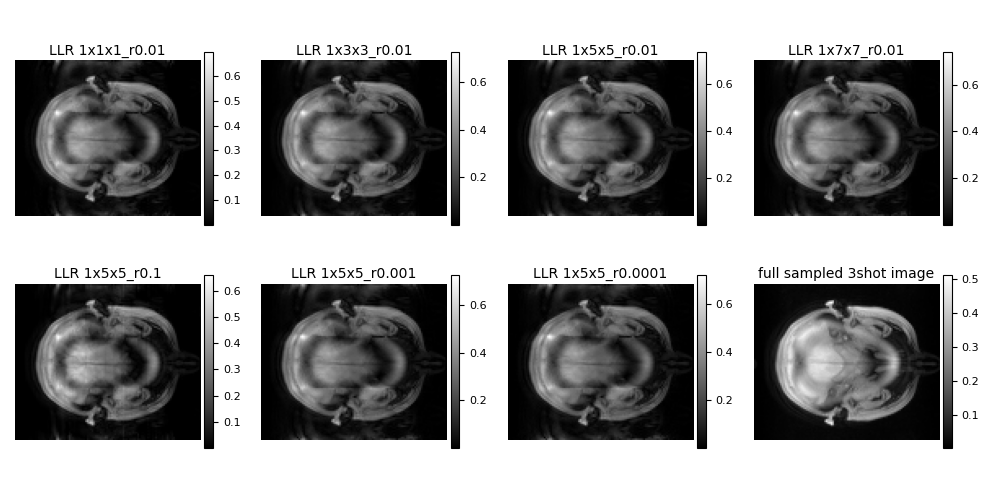

interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=23)…

In [33]:
#view imgs from h5 files (2split) vs a reference (fully sampled 3shot)
import numpy as np
import h5py

data=[]
titles=[]

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'



#LLR recon ( 1x1x1 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x1x1_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x1x1_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR 1x1x1_r0.01')


#LLR recon ( 1x3x3 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x3x3_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x3x3_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR 1x3x3_r0.01')


#LLR recon ( 1x5x5 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR 1x5x5_r0.01')



#LLR recon ( 1x7x7 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x7x7_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x7x7_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR 1x7x7_r0.01')




#LLR recon ( 1x5x5 || r=0.1|| 2_splits)
imgs=[]
imgs_2=[]
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.1_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.1_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR 1x5x5_r0.1')


#LLR recon ( 1x5x5 || r=0.001|| 2_splits)
imgs=[]
imgs_2=[]
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.001_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.001_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR 1x5x5_r0.001')


#LLR recon ( 1x5x5 || r=0.0001|| 2_splits)
imgs=[]
imgs_2=[]
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.0001_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'

# file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.0001_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR 1x5x5_r0.0001')


## fully sampled ACS images
imgs=[]
file='ifft_recon_3shot.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=np.concat([f[k][:] for k in f.keys()],axis=0)
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('fully sampled 3shot shape:',imgs.shape)
# imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
# print('ACS shape after repeat:',imgs.shape)

data.append((imgs))
titles.append('full sampled 3shot image')

del imgs

# plotg(data,cols=3,titles=titles)
plotgRP(data,cols=4,titles=titles,phase=False)
del data

imgs shape after transpose: (17, 10, 96, 114)
imgs_2 shape after transpose: (17, 10, 96, 114)
imgs shape after concatenation: (34, 10, 96, 114)
imgs shape (34, 10, 96, 114)
imgs shape after transpose: (17, 10, 96, 114)
imgs_2 shape after transpose: (17, 10, 96, 114)
imgs shape after concatenation: (34, 10, 96, 114)
imgs shape (34, 10, 96, 114)
imgs shape after transpose: (17, 10, 96, 114)
imgs_2 shape after transpose: (17, 10, 96, 114)
imgs shape after concatenation: (34, 10, 96, 114)
imgs shape (34, 10, 96, 114)
imgs shape after transpose: (17, 10, 96, 114)
imgs_2 shape after transpose: (17, 10, 96, 114)
imgs shape after concatenation: (34, 10, 96, 114)
imgs shape (34, 10, 96, 114)
imgs shape after transpose: (17, 10, 96, 114)
imgs_2 shape after transpose: (17, 10, 96, 114)
imgs shape after concatenation: (34, 10, 96, 114)
imgs shape (34, 10, 96, 114)
<KeysViewHDF5 ['kdat_01', 'kdat_02']>
fully sampled 3shot shape: (34, 10, 96, 114)


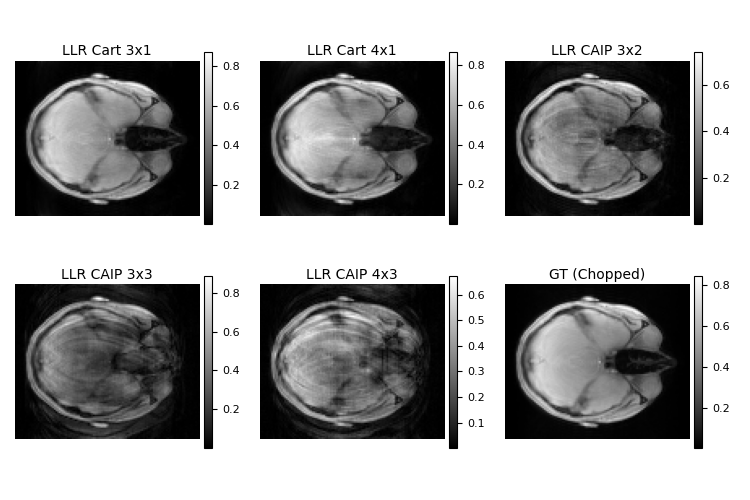

interactive(children=(IntSlider(value=0, description='r', max=33), IntSlider(value=0, description='p', max=9),…

In [14]:
#View Chopped imgs from h5 files (Different US _ 2split LLR) vs a reference (Chopped fully sampled 3shot)
import numpy as np
import h5py

data=[]
titles=[]

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'



#LLR recon ( Cart 3x1 ||1x1x1 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
# file='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_20_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file  ='CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_Cart_3x1_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_Cart_3x1_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR Cart 3x1')


#LLR recon ( Cart 4x1 || 1x5x5 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
file  = 'CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_Cart_4x1_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_Cart_4x1_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR Cart 4x1')


#LLR recon ( CAIP 3x2 ||1x5x5 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
file  = 'CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_CAIP_3x2_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_CAIP_3x2_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR CAIP 3x2')



#LLR recon ( CAIP 3x3||1x5x5 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
file  = 'CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_CAIP_3x3_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_CAIP_3x3_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
imgs_2=np.asarray(imgs_2)
imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
print('imgs_2 shape after transpose:',imgs_2.shape)
imgs=np.concatenate((imgs,imgs_2),axis=0)
print('imgs shape after concatenation:',imgs.shape)
del imgs_2
# imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape',imgs.shape)

data.append(imgs)
titles.append('LLR CAIP 3x3')




#LLR recon ( CAIP 4x3||1x5x5 || r=0.01|| 2_splits)
imgs=[]
imgs_2=[]
file  = 'CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_CAIP_4x3_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
file_2='CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_R34_C44_3shot_chopped_us_CAIP_4x3_yshift_False_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5'
RO_start=0
RO_end=114
with h5py.File(DATA_DIR+file,'r')as f:
    # keys=list(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])
imgs=np.asarray(imgs)
imgs=np.transpose(imgs,(-3,-2,-1,-4))
print('imgs shape after transpose:',imgs.shape)
with h5py.File(DATA_DIR+file_2,'r')as f:
    for RO_idx in range(RO_start,RO_end): 
        imgs_2.append(f[f'CEST_recon_RO_idx_{RO_idx}'][:])       
    imgs_2=np.asarray(imgs_2)
    imgs_2=np.transpose(imgs_2,(-3,-2,-1,-4))
    print('imgs_2 shape after transpose:',imgs_2.shape)
    imgs=np.concatenate((imgs,imgs_2),axis=0)
    print('imgs shape after concatenation:',imgs.shape)
    del imgs_2
    # imgs=np.transpose(imgs,(-3,-2,-1,-4))
    print('imgs shape',imgs.shape)

    data.append(imgs)
    titles.append('LLR CAIP 4x3')

    

imgs=[]
file='ifft_recon_3shot_chopped.h5'
with h5py.File(DATA_DIR+file,'r') as f:
    print(f.keys())
    imgs=np.concat([f[k][:] for k in f.keys()],axis=0)
    # imgs=sp.resize(imgs,f['refs'].attrs['kshape'][-4::])
print('fully sampled 3shot shape:',imgs.shape)
# imgs=np.broadcast_to(imgs[np.newaxis, ...], (34, *imgs.shape))
# print('ACS shape after repeat:',imgs.shape)

data.append((imgs))
titles.append('GT (Chopped)')

del imgs
# plotg(data,cols=3,titles=titles)
plotgRP(data,cols=3,titles=titles,phase=False)
del data

recons shape: (4, 24, 96, 114)
imgs_ax shape: (4, 96, 114)
imgs sag: (4, 96, 24)
imgs sag after resize: (4, 96, 114)


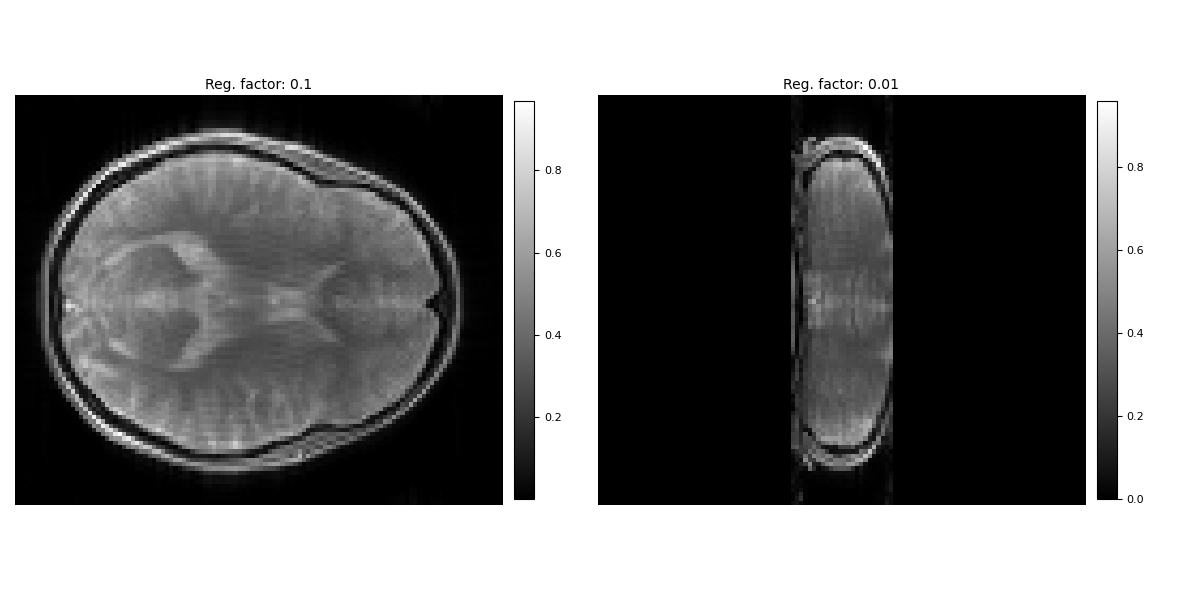

interactive(children=(IntSlider(value=0, description='p', max=3), FloatSlider(value=0.0, description='Min (Bla…

In [ ]:
#Axial and sagittal (Regs) [Grappa3_1shot_Simon1st]
import h5py
import numpy as np
import sigpy as sp
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

reg_fctrs=[0.1,0.01,0.001,0.0001]

# CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.xxxx_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5

RO=114
REP=1
recons=[]
imgs=[]
RO_start=0 #start and end RO position that cover FOV ()
RO_end=114  # ( )

for i in range(len(reg_fctrs)):
    #1st split
    with h5py.File(DATA_DIR+f'CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_{reg_fctrs[i]}_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5','r') as f:
        # print(f.keys())
        for RO_idx in range(RO_start,RO_end): 
            imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:])

        imgs=np.permute_dims(imgs,(1,2,0))
    recons.append(imgs)
    imgs=[]

    # #2nd split    
    # with h5py.File(DATA_DIR+f'CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_{reg_fctrs[i]}_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5','r') as f:
    # # with h5py.File(DATA_DIR+file,'r') as f:
    #     # print(f.keys())
    #     for RO_idx in range(RO_start,RO_end): 
    #         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:])
    #     # # RO_idx=1
    #     # img=f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:]
    #     # img=f[f'recons_L1W'][:]
    #     imgs_2=np.permute_dims(imgs,(1,2,0))
    #     imgs=np.concatenate((imgs_1,imgs_2),axis=0)
    #     del imgs_1, imgs_2
    #     recons.append(imgs)
    #     del imgs


        
    # print(np.shape(imgs))
    # imgs=np.array(imgs)
print('recons shape:',np.shape(recons))
# plotp([ recons[i][36,...], [f'Reg. factor: {reg_fctrs[i]}'] for i in range(len(reg_fctrs))])



part=12 #selected partition for axial view
RO=57 #selected RO position for sagital view || 22 is aronund the artifact
imgs_ax = [recons[i][part, ...] for i in range(len(reg_fctrs))]
imgs_sag = [recons[i][...,RO] for i in range(len(reg_fctrs))]
titles = [f'Reg. factor: {r}' for r in reg_fctrs]

imgs_sag=np.permute_dims(imgs_sag,(0,2,1))
print('imgs_ax shape:',np.shape(imgs_ax))
print('imgs sag:',np.shape(imgs_sag))
imgs_sag = [sp.resize(imgs_sag[i],imgs_ax[0].shape) for i in range(len(reg_fctrs))]
print('imgs sag after resize:',np.shape(imgs_sag))

# plotp(imgs, titles=titles)
# plotw(imgs, titles=titles)
# imgs=np.array(imgs)
plotpg([imgs_ax,imgs_sag],cols=2, titles=titles)
# ani=plotani(imgs, titles,interval=2)
# from IPython.display import HTML
# HTML(ani.to_jshtml())

# ani.save('LLR_5x5_regs.gif', fps=.5, writer='pillow')
# # plotw(np.squeeze(imgs))

del imgs_ax
del imgs_sag

recons shape: (4, 24, 96, 114)
imgs_ax shape: (4, 96, 114)
imgs sag: (4, 96, 24)
imgs sag after resize: (4, 96, 114)


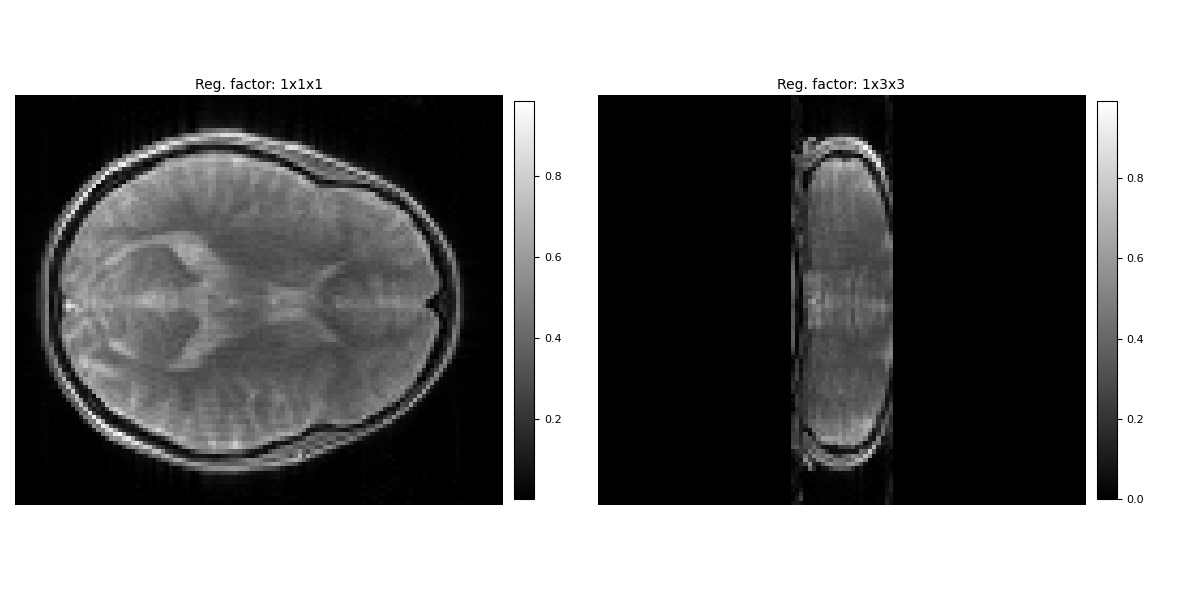

interactive(children=(IntSlider(value=0, description='p', max=3), FloatSlider(value=0.0, description='Min (Bla…

In [ ]:
#Axial and sagittal view (LLR grid size) [Grappa3_1shot_Simon1st]
import h5py
import h5py
import numpy as np
import sigpy as sp

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA/'

# CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_xxxxxx_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5

grid_sizes=['1x1x1','1x3x3','1x5x5','1x7x7']
# file= 'CEST_LLR_recons_Reps_1_10_RO_1_160_1x5x5_r_0.0001_i_30.h5'

RO=114
REP=1
recons=[]
imgs=[]
RO_start=0 #start and end RO position that cover FOV (0 || 15 || 80)
RO_end=114 # ( 146 || 160 || 205 || 244 )
# RO_end=146

for i in range(len(grid_sizes)):
    with h5py.File(DATA_DIR+f'CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_{grid_sizes[i]}_r_0.01_i_30_2D_kdat_3D_R34_C44_1shot_mps_c_0_t0.05_w_24_kw_6_sp_ksp.h5','r') as f:
    # with h5py.File(DATA_DIR+file,'r') as f:
        # print(f.keys())
        for RO_idx in range(RO_start,RO_end): 
            imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:])
        # # RO_idx=1
        # img=f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:]
        # img=f[f'recons_L1W'][:]
        imgs=np.permute_dims(imgs,(1,2,0))
        recons.append(imgs)
        imgs=[]
    # print(np.shape(imgs))
    # imgs=np.array(imgs)
print('recons shape:',np.shape(recons))
# plotp([ recons[i][36,...], [f'Reg. factor: {reg_fctrs[i]}'] for i in range(len(reg_fctrs))])

part=12 #selected partition for axial view
RO=57 #selected RO position for sagital view || 22 is aronund the artifact
imgs_ax = [recons[i][part, ...] for i in range(len(grid_sizes))]
imgs_sag = [recons[i][...,RO] for i in range(len(grid_sizes))]
titles = [f'Reg. factor: {r}' for r in grid_sizes]

imgs_sag=np.permute_dims(imgs_sag,(0,2,1))
print('imgs_ax shape:',np.shape(imgs_ax))
print('imgs sag:',np.shape(imgs_sag))
imgs_sag = [sp.resize(imgs_sag[i],imgs_ax[0].shape) for i in range(len(reg_fctrs))]
print('imgs sag after resize:',np.shape(imgs_sag))

# plotp(imgs, titles,vmax=np.max(np.abs(imgs)))
plotpg([imgs_ax,imgs_sag],cols=2, titles=titles)
# ani=plotani(imgs, titles,interval=2)
# from IPython.display import HTML
# HTML(ani.to_jshtml())

# ani.save('LLR_5x5_regs.gif', fps=.5, writer='pillow')
# # plotw(np.squeeze(imgs))
del imgs_ax
del imgs_sag